In [1]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    try:
        print('GPU name:', torch.cuda.get_device_name(0))
    except:
        pass


Mounted at /content/drive
GPU available: True
GPU name: Tesla T4


In [2]:

!pip install -q albumentations==1.3.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 11.1 MB/s eta 0:00:00


In [3]:

import os
from PIL import Image, ImageDraw
import numpy as np

base_dir = '/content/synthetic_data'
images_dir = os.path.join(base_dir, 'images')
masks_dir = os.path.join(base_dir, 'masks')
os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

num_samples = 120   # small and fast
img_size = (128, 128)

np.random.seed(42)

for i in range(num_samples):
    img = Image.new('RGB', img_size, (255,255,255))
    mask = Image.new('L', img_size, 0)
    draw_img = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    shape_type = np.random.choice(['circle','rectangle','ellipse'])
    x0, y0 = np.random.randint(8, 48), np.random.randint(8, 48)
    w, h = np.random.randint(30, 80), np.random.randint(30, 80)
    x1, y1 = min(x0+w, img_size[0]-1), min(y0+h, img_size[1]-1)

    if shape_type == 'circle' or shape_type == 'ellipse':
        draw_img.ellipse([x0,y0,x1,y1], fill=(np.random.randint(50,230), np.random.randint(50,230), np.random.randint(50,230)))
        draw_mask.ellipse([x0,y0,x1,y1], fill=255)
    else:
        draw_img.rectangle([x0,y0,x1,y1], fill=(np.random.randint(50,230), np.random.randint(50,230), np.random.randint(50,230)))
        draw_mask.rectangle([x0,y0,x1,y1], fill=255)

    img.save(os.path.join(images_dir, f'img_{i:03d}.png'))
    mask.save(os.path.join(masks_dir, f'mask_{i:03d}.png'))

print('Created', num_samples, 'synthetic images at', base_dir)

Created 120 synthetic images at /content/synthetic_data


In [4]:

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import numpy as np
import os

class SyntheticDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform_img=None, transform_mask=None):
        self.images = sorted([f for f in os.listdir(images_dir) if f.lower().endswith('.png')])
        self.masks  = sorted([f for f in os.listdir(masks_dir) if f.lower().endswith('.png')])
        self.pairs = [fname for fname in self.images if fname.replace('img_','mask_') in self.masks]
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name = self.pairs[idx]
        mask_name = img_name.replace('img_','mask_')
        img = Image.open(os.path.join(self.images_dir, img_name)).convert('RGB')
        mask = Image.open(os.path.join(self.masks_dir, mask_name)).convert('L')
        if self.transform_img:
            img = self.transform_img(img)
        if self.transform_mask:
            mask = self.transform_mask(mask)
        mask = (mask>0).float()
        return img, mask

transform_img = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])
transform_mask = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

dataset = SyntheticDataset(images_dir, masks_dir, transform_img, transform_mask)
print('Dataset size:', len(dataset))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print('Train / Val sizes:', len(train_dataset), len(val_dataset))

Dataset size: 120
Train / Val sizes: 96 24


In [5]:

import torch.nn as nn
import torchvision.models.segmentation as segmentation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = segmentation.deeplabv3_resnet50(pretrained=False, num_classes=1)  # binary
model = model.to(device)
print('Model created, device=', device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


Model created, device= cuda


In [6]:

import torch.optim as optim
from tqdm import tqdm

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [train]')
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)['out']  # (B,1,H,W)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_train = sum(train_losses)/len(train_losses)

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)['out']
            loss = criterion(outputs, masks)
            val_losses.append(loss.item())
    avg_val = sum(val_losses)/len(val_losses)
    print(f'Epoch {epoch+1}/{num_epochs} -- train_loss: {avg_train:.4f}, val_loss: {avg_val:.4f}')

Epoch 1/10 [train]: 100%|██████████| 12/12 [00:05<00:00,  2.24it/s, loss=0.1164]


Epoch 1/10 -- train_loss: 0.3194, val_loss: 1.3994


Epoch 2/10 [train]: 100%|██████████| 12/12 [00:02<00:00,  4.16it/s, loss=0.0772]


Epoch 2/10 -- train_loss: 0.0909, val_loss: 0.1359


Epoch 3/10 [train]: 100%|██████████| 12/12 [00:02<00:00,  4.78it/s, loss=0.0564]


...

Epoch 8/10 -- train_loss: 0.0284, val_loss: 0.0283


Epoch 9/10 [train]: 100%|██████████| 12/12 [00:02<00:00,  5.12it/s, loss=0.0250]


Epoch 9/10 -- train_loss: 0.0267, val_loss: 0.0251


Epoch 10/10 [train]: 100%|██████████| 12/12 [00:02<00:00,  5.07it/s, loss=0.0250]


Epoch 10/10 -- train_loss: 0.0257, val_loss: 0.0245


In [7]:

save_dir = '/content/drive/MyDrive/VISION_AI/Models'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'synthetic_deeplabv3.pth')
torch.save(model.state_dict(), save_path)
print('Model saved to', save_path)

Model saved to /content/drive/MyDrive/VISION_AI/Models/synthetic_deeplabv3.pth


In [8]:

import numpy as np
import torch

def iou_score(preds, masks, threshold=0.5):
    preds = (preds > threshold).int()
    masks = masks.int()
    intersection = (preds & masks).sum(dim=(1,2,3)).float()
    union = (preds | masks).sum(dim=(1,2,3)).float()
    iou = (intersection / (union + 1e-6)).mean().item()
    return iou

def dice_score(preds, masks, threshold=0.5):
    preds = (preds > threshold).int()
    masks = masks.int()
    intersection = (preds & masks).sum(dim=(1,2,3)).float()
    dice = (2*intersection / (preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()
    return dice

model.eval()
ious, dices = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = torch.sigmoid(model(imgs)['out'])
        ious.append(iou_score(outputs, masks))
        dices.append(dice_score(outputs, masks))
print('Val IoU:', np.mean(ious), 'Val Dice:', np.mean(dices))

Val IoU: 0.9361022512118021 Val Dice: 0.96685391664505


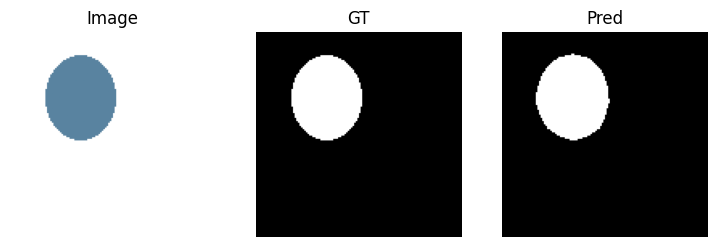

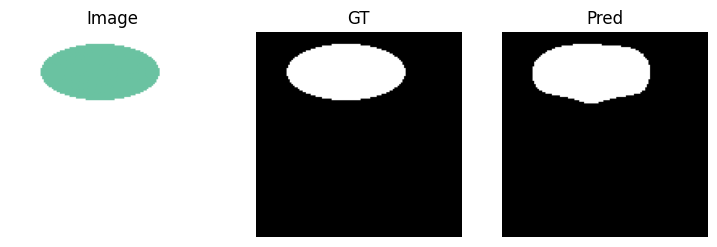

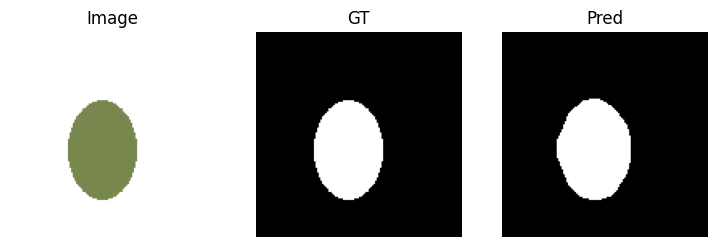

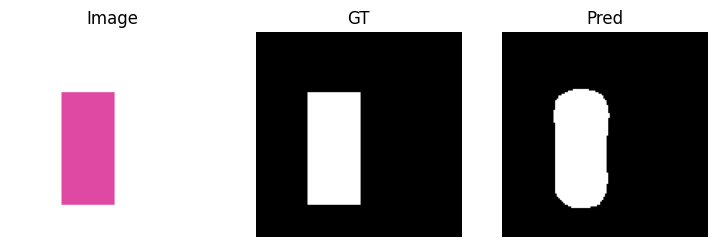

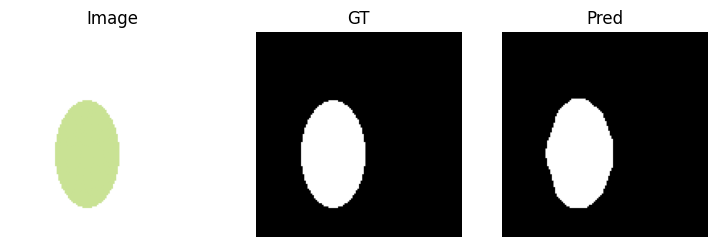

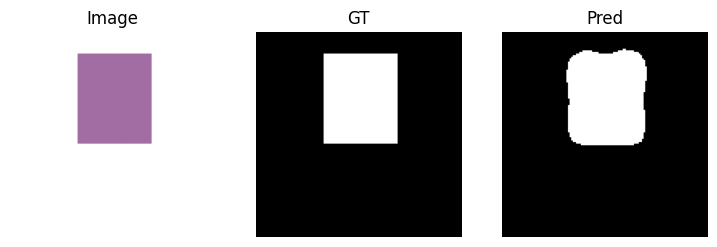

Saved example predictions to /content/drive/MyDrive/VISION_AI/Predictions


In [9]:

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

out_pred_dir = '/content/drive/MyDrive/VISION_AI/Predictions'
os.makedirs(out_pred_dir, exist_ok=True)

model.eval()
count = 0
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = torch.sigmoid(model(imgs)['out'])
        preds = (outputs > 0.5).float()
        for i in range(imgs.size(0)):
            img_np = imgs[i].cpu().permute(1,2,0).numpy()
            gt = masks[i].cpu().squeeze().numpy()
            pred = preds[i].cpu().squeeze().numpy()
            fig, axs = plt.subplots(1,3,figsize=(9,3))
            axs[0].imshow(img_np); axs[0].set_title('Image'); axs[0].axis('off')
            axs[1].imshow(gt, cmap='gray'); axs[1].set_title('GT'); axs[1].axis('off')
            axs[2].imshow(pred, cmap='gray'); axs[2].set_title('Pred'); axs[2].axis('off')
            plt.show()
            pred_img = Image.fromarray((pred*255).astype(np.uint8))
            pred_img.save(os.path.join(out_pred_dir, f'pred_{count:03d}.png'))
            count += 1
            if count >= 6:
                break
        if count >= 6:
            break

print('Saved example predictions to', out_pred_dir)

### Notebook ready. Run in Colab with GPU. The notebook will save model & example predictions to your Google Drive under `VISION_AI/Models` and `VISION_AI/Predictions`.